In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("test.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
# image information
print(f"Shape  : {img.shape}")
print(f"Size   : {img.size}")
print(f"dtype  : {img.dtype}")
print(f"Max px : {img.max()}")
print(f"Min px : {img.min()}")

Shape  : (1024, 1024, 3)
Size   : 3145728
dtype  : uint8
Max px : 255
Min px : 0


In [4]:
# convert it to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

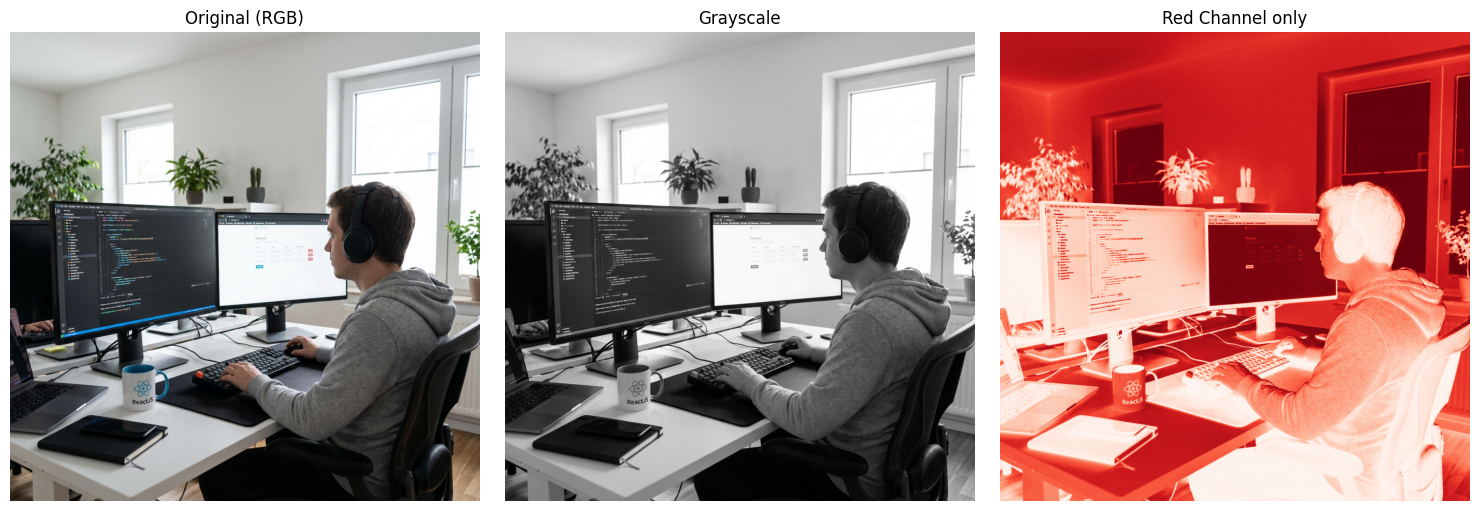

In [5]:
# show
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original (RGB)")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(img_rgb[:, :, 0], cmap="Reds")
axes[2].set_title("Red Channel only")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("output.png")
plt.show()

In [6]:

# APPLY Filters ──────────────────────────
average   = cv2.blur(img_rgb, (5, 5))
gaussian  = cv2.GaussianBlur(img_rgb, (5, 5), 0)
median    = cv2.medianBlur(img_rgb, 5)

sharp_kernel = np.array([[ 0, -1,  0],
                          [-1,  5, -1],
                          [ 0, -1,  0]])
sharpened = cv2.filter2D(img_rgb, -1, sharp_kernel)


In [7]:

# ── 3. إضافة Noise عشان نشوف الفرق ───────────────
noise      = np.random.randint(0, 50, img_rgb.shape, dtype=np.uint8)
noisy_img  = cv2.add(img_rgb, noise)
denoised   = cv2.GaussianBlur(noisy_img, (5, 5), 0)


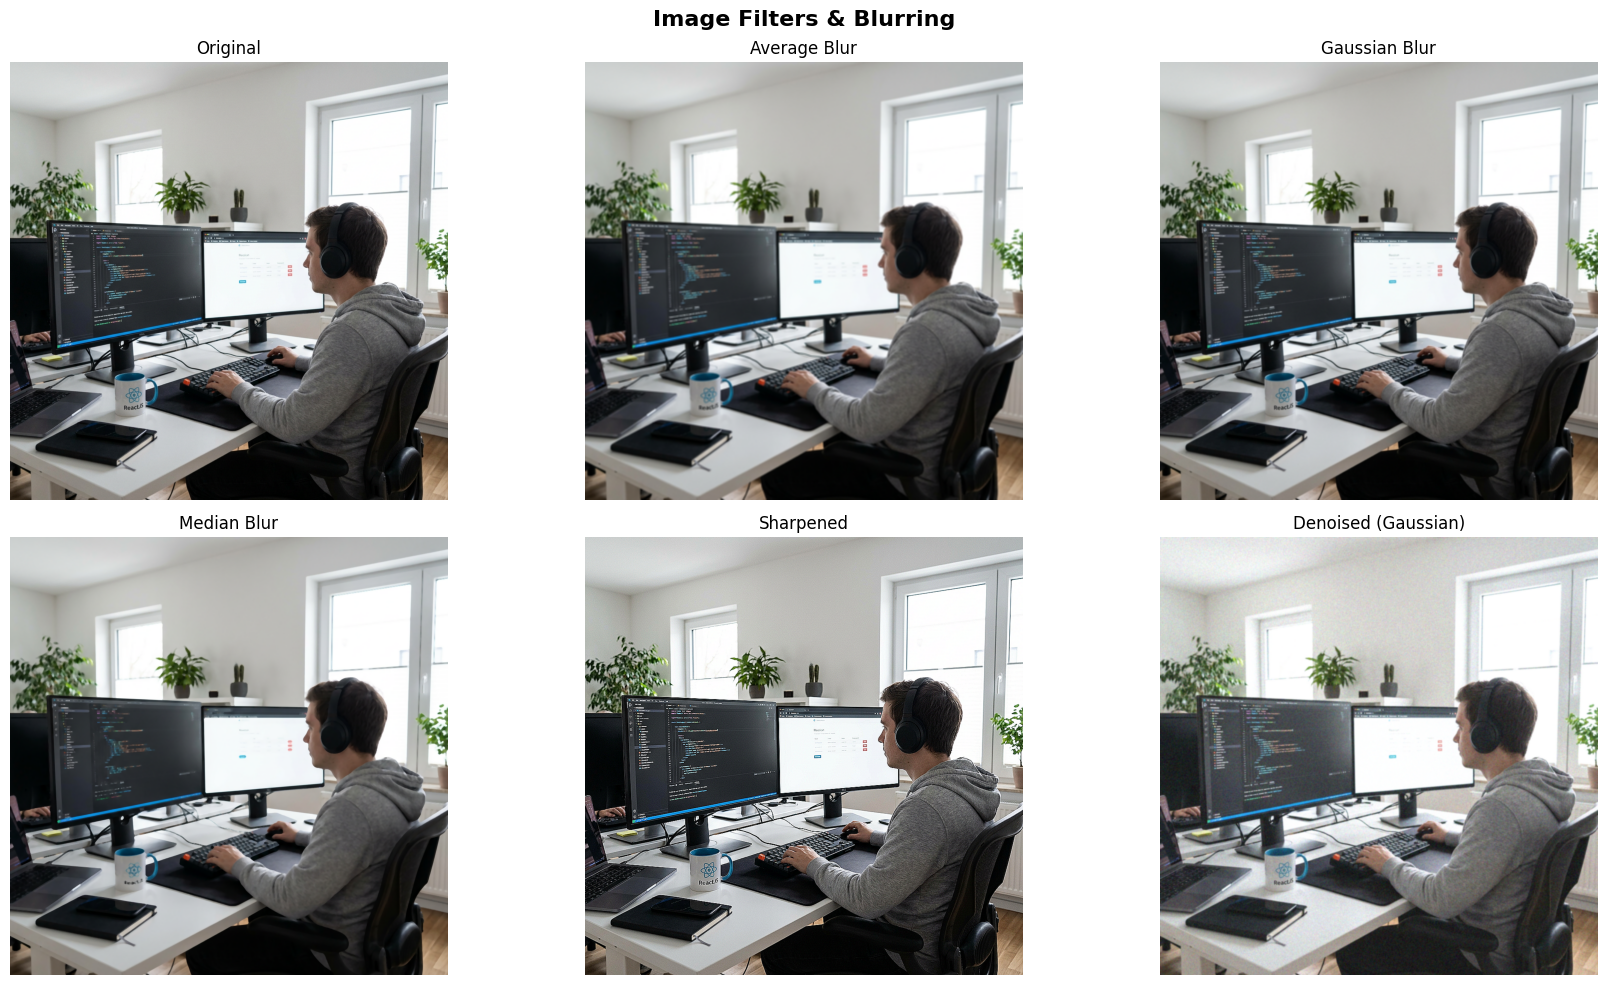

✅ Done! output_filters.png saved.


In [8]:

# ── 4. عرض كل النتائج ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Image Filters & Blurring", fontsize=16, fontweight="bold")

images = [img_rgb, average, gaussian, median, sharpened, denoised]
titles = ["Original", "Average Blur", "Gaussian Blur",
          "Median Blur", "Sharpened", "Denoised (Gaussian)"]

for ax, image, title in zip(axes.flat, images, titles):
    ax.imshow(image)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig("output_filters.png", dpi=150)
plt.show()
print("✅ Done! output_filters.png saved.")